# NumPy · pandas · Matplotlib · Seaborn 기초 실습

데이터 분석의 필수 Python 라이브러리 네 가지—NumPy, pandas, Matplotlib, Seaborn—의 가장 핵심적인 기능을 **실습 위주**로 소개합니다.

## 강의 목표
- Python 환경(Jupyter Notebook)에서 데이터를 다루는 기본 능력 습득
- NumPy를 사용하여 다차원 배열 생성·연산 이해
- pandas를 통해 표 형태의 데이터를 불러오고(DataFrame), 선택·집계·가공 실습
- Matplotlib로 데이터 시각화 기초 플롯 작성
- Seaborn으로 데이터 시각화 기초 플롯 작성

> 📌 **✏️ 표시가 붙은 "연습문제"는 직접 풀어 보는 칸입니다.** 먼저 스스로 작성해 본 뒤 정답을 확인하세요.

In [2]:
# Google Colab 환경 설정
# 한글 폰트 설치 (Colab에서 한글이 깨지는 것을 방지)
!apt-get update -qq
!apt-get install -y fonts-nanum fonts-nanum-coding fonts-nanum-extra -qq

# 폰트 캐시 갱신
!fc-cache -fv

# 라이브러리 설치
!pip install -q numpy pandas matplotlib seaborn

print("✅ 폰트 설치 완료! 런타임을 재시작하면 한글이 정상적으로 표시됩니다.")
print("⚠️ [런타임] > [런타임 다시 시작]을 클릭한 후, 아래 셀부터 다시 실행하세요.")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fonts-nanum-coding (2.5-3) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/s

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 한글 폰트 설정 (Google Colab 환경)
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔고딕 폰트 경로 설정 및 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# seaborn 스타일 설정 (폰트 설정보다 먼저!)
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0)

# 한글 폰트 설정 (seaborn 설정 후에 적용해야 덮어쓰이지 않음)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 확인
print("✅ 라이브러리 및 한글 폰트 설정 완료!")
print(f"현재 폰트: {plt.rcParams['font.family']}")

✅ 라이브러리 및 한글 폰트 설정 완료!
현재 폰트: ['NanumGothic']


### Jupyter 기본 단축키
- **셀 실행**: `Shift + Enter`
- **새 셀 추가**: `B`(아래) 또는 `A`(위)

### 1.1 NumPy 배열 생성하기

NumPy는 **수치 계산**을 위한 핵심 라이브러리입니다. 파이썬 리스트보다 빠르고 효율적으로 대량의 데이터를 처리할 수 있습니다.

## 1. NumPy 기초

> 📌 **3차시 복습** — 3차시 *벡터와 행렬*에서 배운 NumPy 배열을, 이번엔 **데이터 분석의 출발점**으로 짧게 복습합니다. 이미 익숙하면 빠르게 넘어가도 좋아요.

In [2]:
# 파이썬 리스트 vs NumPy 배열 비교
print("=== 파이썬 리스트 ===")
python_list = [1, 2, 3, 4, 5]
print("리스트:", python_list)
print("타입:", type(python_list))

print("\n=== NumPy 배열 ===")
numpy_array = np.array([1, 2, 3, 4, 5])
print("배열:", numpy_array)
print("타입:", type(numpy_array))

# 연산 비교
print("\n=== 연산 비교 ===")
print("리스트 * 2:", python_list * 2)   # 리스트가 통째로 2번 반복
print("배열 * 2:", numpy_array * 2)    # 각 원소에 2를 곱함

=== 파이썬 리스트 ===
리스트: [1, 2, 3, 4, 5]
타입: <class 'list'>

=== NumPy 배열 ===
배열: [1 2 3 4 5]
타입: <class 'numpy.ndarray'>

=== 연산 비교 ===
리스트 * 2: [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
배열 * 2: [ 2  4  6  8 10]


In [3]:
# NumPy 배열 생성의 다양한 방법
print("=== 다양한 배열 생성 방법 ===")

# 1. 0으로 채워진 배열
zeros = np.zeros(5)
print("np.zeros(5):", zeros)

# 2. 1로 채워진 배열
ones = np.ones(5)
print("np.ones(5):", ones)

# 3. 연속된 숫자 배열
arange = np.arange(1, 10)
print("np.arange(1, 10):", arange)

# 4. 일정 간격으로 나눈 배열
linspace = np.linspace(0, 1, 5)
print("np.linspace(0, 1, 5):", linspace)

=== 다양한 배열 생성 방법 ===
np.zeros(5): [0. 0. 0. 0. 0.]
np.ones(5): [1. 1. 1. 1. 1.]
np.arange(1, 10): [1 2 3 4 5 6 7 8 9]
np.linspace(0, 1, 5): [0.   0.25 0.5  0.75 1.  ]


In [4]:
# NumPy 배열의 기본 연산
arr = np.array([1, 2, 3, 4, 5])
print("원본 배열:", arr)

print("\n=== 사칙연산 ===")
print("arr + 10:", arr + 10)
print("arr - 2:", arr - 2)
print("arr * 3:", arr * 3)
print("arr / 2:", arr / 2)

print("\n=== 통계 함수 ===")
print("합계 (sum):", arr.sum())
print("평균 (mean):", arr.mean())
print("최댓값 (max):", arr.max())
print("최솟값 (min):", arr.min())
print("표준편차 (std):", arr.std())

원본 배열: [1 2 3 4 5]

=== 사칙연산 ===
arr + 10: [11 12 13 14 15]
arr - 2: [-1  0  1  2  3]
arr * 3: [ 3  6  9 12 15]
arr / 2: [0.5 1.  1.5 2.  2.5]

=== 통계 함수 ===
합계 (sum): 15
평균 (mean): 3.0
최댓값 (max): 5
최솟값 (min): 1
표준편차 (std): 1.4142135623730951


In [5]:
# NumPy 배열 인덱싱과 슬라이싱
arr = np.array([10, 20, 30, 40, 50, 60, 70])
print("배열:", arr)

print("\n=== 인덱싱 (특정 위치의 값 가져오기) ===")
print("arr[0] - 첫 번째 원소:", arr[0])
print("arr[3] - 네 번째 원소:", arr[3])
print("arr[-1] - 마지막 원소:", arr[-1])

print("\n=== 슬라이싱 (범위로 가져오기) ===")
print("arr[1:4] - 2~4번째:", arr[1:4])
print("arr[:3] - 처음부터 3번째:", arr[:3])
print("arr[4:] - 5번째부터 끝까지:", arr[4:])
print("arr[::2] - 2칸씩 건너뛰기:", arr[::2])

배열: [10 20 30 40 50 60 70]

=== 인덱싱 (특정 위치의 값 가져오기) ===
arr[0] - 첫 번째 원소: 10
arr[3] - 네 번째 원소: 40
arr[-1] - 마지막 원소: 70

=== 슬라이싱 (범위로 가져오기) ===
arr[1:4] - 2~4번째: [20 30 40]
arr[:3] - 처음부터 3번째: [10 20 30]
arr[4:] - 5번째부터 끝까지: [50 60 70]
arr[::2] - 2칸씩 건너뛰기: [10 30 50 70]


In [6]:
# 2차원 배열 (행렬) 만들기
arr_2d = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("2차원 배열:")
print(arr_2d)
print("\n행 선택 (첫 번째 행):", arr_2d[0])
print("열 선택 (첫 번째 열):", arr_2d[:, 0])
print("특정 원소 (2행 3열):", arr_2d[1, 2])

2차원 배열:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

행 선택 (첫 번째 행): [1 2 3]
열 선택 (첫 번째 열): [1 4 7]
특정 원소 (2행 3열): 6


In [13]:
import numpy as np
# ndarray 생성 & 속성 확인
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(arr)
print('shape:', arr.shape, 'dtype:', arr.dtype)

[[1 2 3]
 [4 5 6]]
shape: (2, 3) dtype: int64


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 1-1 짝수 배열 만들기</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 0~9 중 <b>짝수만</b> 담은 1차원 배열을 만들고 <code>dtype</code>을 확인하세요.<br><b>힌트</b> &nbsp; <code>np.arange(시작, 끝, 간격)</code> · 배열의 자료형은 <code>.dtype</code><br><b>예상</b> &nbsp; <code>[0 2 4 6 8]</code> · dtype 은 정수형(int64)
</div>
</div>

In [9]:
# ✏️ 연습 1-1 — 빈칸(____)을 채워 보세요
even = np.arange(0, 10, 2)   # 짝수만 남기려면 몇 칸씩 건너뛸지
print(even, even.dtype)          # 배열의 자료형을 알려주는 속성

[0 2 4 6 8] int64


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 1-2 3의 배수 통계</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 1~100 중 <b>3의 배수만</b> 담은 배열을 만들고 <b>평균</b>과 <b>합</b>을 구하세요.<br><b>힌트</b> &nbsp; <code>np.arange(시작, 끝, 간격)</code> 로 등차 배열 · 평균·합계는 배열의 통계 메서드<br><b>예상</b> &nbsp; 평균 약 51 · 합 1683
</div>
</div>

In [10]:
# ✏️ 연습 1-2 — 빈칸을 채워 보세요
multiples_of_3 = np.arange(3, 101, 3)   # 몇 칸씩 건너뛸지
print('평균:', multiples_of_3.mean())       # 평균을 구하는 메서드
print('합:', multiples_of_3.sum())         # 합계를 구하는 메서드

평균: 51.0
합: 1683


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 1-3 무작위 생성과 정렬 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 0~1 사이 균등분포에서 <b>10개</b>를 무작위로 만들고 <code>np.sort</code>로 <b>오름차순</b> 정렬하세요.<br><b>힌트</b> &nbsp; 무작위 <code>np.random.rand(10)</code> · 정렬 <code>np.sort(배열)</code><br><b>예상</b> &nbsp; 작은 값 → 큰 값 순으로 줄세운 10개
</div>
</div>

In [11]:
# ✏️ 직접 작성 — rand(10) 으로 무작위 10개를 만들고 np.sort 로 오름차순 정렬
nums = np.random.rand(10)          # ← 0~1 균등분포에서 10개를 무작위로 생성
sorted_nums = np.sort(nums)   # ← 위 배열을 오름차순으로 정렬한 새 배열
print(sorted_nums)

[0.01880962 0.17255198 0.19734179 0.21675457 0.33568315 0.37184828
 0.5135436  0.62309977 0.73619377 0.94431333]


### 2.1 Series 이해하기

Series는 **1차원 데이터**입니다. 엑셀의 한 열(column)이라고 생각하면 됩니다.

In [12]:
# Series 만들기 - 가장 기본적인 방법
scores = pd.Series([85, 90, 78, 92, 88])
print("기본 Series:")
print(scores)
print("\n인덱스:", scores.index.tolist())
print("값:", scores.values)

기본 Series:
0    85
1    90
2    78
3    92
4    88
dtype: int64

인덱스: [0, 1, 2, 3, 4]
값: [85 90 78 92 88]


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 2-1 Series 다뤄 보기</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 위에서 만든 <code>scores</code> Series의 <b>평균</b>과 <b>최댓값</b>을 구해 출력하세요.<br><b>힌트</b> &nbsp; Series도 배열처럼 <code>.mean()</code> · <code>.max()</code> 를 씁니다.<br><b>예상</b> &nbsp; 평균 86.6 · 최댓값 92
</div>
</div>

In [14]:
# ✏️ 연습 2-1 — 빈칸(____)을 채워 보세요
print("평균:", scores.mean())   # 평균을 구하는 메서드
print("최댓값:", scores.max())  # 최댓값을 구하는 메서드

평균: 86.6
최댓값: 92


### 2.2 DataFrame 이해하기

DataFrame은 **2차원 표 데이터**입니다. 엑셀 시트 전체라고 생각하면 됩니다.

In [15]:
# DataFrame 만들기 - 학생 성적표 예제
students = pd.DataFrame({
    '이름': ['김철수', '이영희', '박민수', '최지연', '정대호'],
    '국어': [85, 90, 78, 92, 88],
    '영어': [88, 95, 82, 89, 91],
    '수학': [90, 87, 80, 95, 85]
})
print("학생 성적표:")
students

학생 성적표:


,이름,국어,영어,수학
0,김철수,85,88,90
1,이영희,90,95,87
2,박민수,78,82,80
3,최지연,92,89,95
4,정대호,88,91,85


In [16]:
# DataFrame 기본 정보 확인
print("=== DataFrame 기본 정보 ===")
print("행의 수:", len(students))
print("열(컬럼) 이름:", students.columns.tolist())
print("데이터 형태 (행, 열):", students.shape)

print("\n=== 특정 열 선택하기 ===")
print("이름 열만 선택:")
print(students['이름'])

print("\n국어 점수만 선택:")
print(students['국어'])

=== DataFrame 기본 정보 ===
행의 수: 5
열(컬럼) 이름: ['이름', '국어', '영어', '수학']
데이터 형태 (행, 열): (5, 4)

=== 특정 열 선택하기 ===
이름 열만 선택:
0    김철수
1    이영희
2    박민수
3    최지연
4    정대호
Name: 이름, dtype: object

국어 점수만 선택:
0    85
1    90
2    78
3    92
4    88
Name: 국어, dtype: int64


In [17]:
# 새로운 열 추가하기 - 평균 계산
students['평균'] = (students['국어'] + students['영어'] + students['수학']) / 3
print("평균 열 추가됨:")
students

평균 열 추가됨:


,이름,국어,영어,수학,평균
0,김철수,85,88,90,87.666667
1,이영희,90,95,87,90.666667
2,박민수,78,82,80,80.000000
3,최지연,92,89,95,92.000000
4,정대호,88,91,85,88.000000


In [18]:
# 조건으로 데이터 필터링하기
print("=== 조건부 필터링 ===")

# 평균이 88 이상인 학생
print("평균 88점 이상인 학생:")
print(students[students['평균'] >= 88])

print("\n수학 90점 이상인 학생:")
print(students[students['수학'] >= 90])

=== 조건부 필터링 ===
평균 88점 이상인 학생:
    이름  국어  영어  수학         평균
1  이영희  90  95  87  90.666667
3  최지연  92  89  95  92.000000
4  정대호  88  91  85  88.000000

수학 90점 이상인 학생:
    이름  국어  영어  수학         평균
0  김철수  85  88  90  87.666667
3  최지연  92  89  95  92.000000


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 2-2 DataFrame 필터 + 열 선택 + 정렬</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>students</code> 에서 <b>수학 점수가 88 이상</b>인 학생의 <code>'이름'</code>·<code>'수학'</code> 열만 골라, 수학 점수 <b>내림차순</b>으로 출력하세요.<br><b>힌트</b> &nbsp; 필터 &middot; 두 열만 <code>[['이름','수학']]</code> &middot; 정렬 <code>.sort_values('수학', ascending=False)</code><br><b>예상</b> &nbsp; 최지연 95 · 김철수 90
</div>
</div>

In [20]:
# ✏️ 연습 2-2 — 빈칸(____)을 채워 보세요
result = students[students['수학'] >= 88][['이름', '수학']]   # 수학 88 이상, 두 열만
print(result.sort_values('수학', ascending=False))              # 내림차순

    이름  수학
3  최지연  95
0  김철수  90


In [23]:
random_nums = np.random.rand(10)
sorted_random = np.sort(random_nums)
print('원본 랜덤 수:', random_nums)
print('정렬된 랜덤 수:', sorted_random)

원본 랜덤 수: [0.92951588 0.46427391 0.69984479 0.15186828 0.12143113 0.90503628
 0.90512124 0.30261806 0.02796893 0.32518215]
정렬된 랜덤 수: [0.02796893 0.12143113 0.15186828 0.30261806 0.32518215 0.46427391
 0.69984479 0.90503628 0.90512124 0.92951588]


## 2. pandas 기초

- Python에서 가장 많이 사용하는 데이터 분석/조작 라이브러리    
- Excel 처럼 표 형태의 정형 데이터를 쉽게 다룰 수 있는 라이브러리    

> 🆕 **여기부터 새로 배웁니다** — pandas는 표(엑셀 같은) 데이터를 다루는 도구로 4차시에서 처음 등장합니다. 이어지는 Matplotlib·Seaborn(시각화)도 새로 배우는 내용입니다.

In [ ]:
# Series & DataFrame
s = pd.Series([10, 15, 7], index=['서울', '부산', '대구'])
df = pd.DataFrame({
    'name': ['Ann', 'Bob', 'Ceci'],
    'age': [23, 25, 22],
    'major': ['Korean', 'Economics', 'Physics']
})

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">⚠️ 흔한 실수 ② · 필터한 결과에 값 대입 — 결과를 예측해 보세요</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>상황</b> &nbsp; 위에서 만든 <code>df</code> 에서 <code>age >= 24</code> 인 사람의 <code>major</code> 를 <code>'???'</code> 로 바꾸려고 <b>필터한 결과에 바로 대입</b>합니다.<br><b>예측</b> &nbsp; 원본 <code>df</code> 의 major 가 정말 바뀔까요? 아니면 조용히 그대로일까요?
</div>
</div>

In [ ]:
# ⚠️ 흔한 실수 — df[조건]['열'] = 값  (chained assignment)
df[df['age'] >= 24]['major'] = '???'   # 경고가 뜨고, 원본은 안 바뀐다
print(df)   # major 를 확인 — '???' 로 바뀌었을까?

<details>
<summary><b>🔑 왜 이렇게 되나 · 올바른 코드</b></summary>

<code>df[df['age']>=24]</code> 는 원본이 아니라 <b>임시 사본</b>이라, 여기에 대입해도 원본은 <b>그대로</b>입니다(위 출력의 major 가 안 바뀐 것을 확인하세요). 다행히 <b>최신 pandas(3.0+)는 <code>ChainedAssignmentError</code> 경고</b>로 ‘이건 원본에 반영 안 된다’고 알려줍니다 — 예전엔 이 경고조차 없어 버그를 놓치기 쉬웠어요. 한 번에 지정하는 <code>.loc</code> 을 쓰세요.

```python
df.loc[df['age'] >= 24, 'major'] = '???'   # 행/열을 한 번에 지정 → 원본이 정확히 바뀐다
print(df)
```

👉 <b>교훈</b> : 값을 <b>바꿀 때</b>는 대괄호를 이어 쓰지 말고 <code>.loc[행, 열]</code> 하나로.

</details>

In [ ]:
print(s)

In [ ]:
df.head()

In [ ]:
#`age` 컬럼의 평균을 구하기
df['age'].mean()

#### iris 데이터셋 조작하기

Iris 데이터셋(붓꽃 데이터셋)은 머신러닝과 통계학 입문자들에게 가장 널리 사용되는 고전(classic) 데이터셋

각 샘플은 4가지 특징(feature) 을 가지고 있습니다:
1. sepal length (꽃받침 길이)   
2. sepal width (꽃받침 폭)   
3. petal length (꽃잎 길이)
4. petal width (꽃잎 폭)

In [ ]:
# CSV 읽기 예시 (인터넷 필요)
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
iris = pd.read_csv(url)
iris.head()

In [ ]:
# 1. 특정 열만 선택하기
print("sepal_length 열만 선택:")
print(iris['sepal_length'].head())

print("\n여러 열 선택:")
selected_cols = iris[['sepal_length', 'species']]
print(selected_cols.head())


In [ ]:
# 2. 특정 열 삭제하기 (원본은 유지)
print("petal_width 열을 제외한 데이터:")
iris_no_petal_width = iris.drop('petal_width', axis=1)
print(iris_no_petal_width.head())

print("\n여러 열 삭제:")
iris_minimal = iris.drop(['petal_length', 'petal_width'], axis=1)
print(iris_minimal.head())


In [ ]:
# 3. 조건부 행 선택 (필터링)
print("sepal_length가 5.0보다 큰 행들:")
large_sepals = iris[iris['sepal_length'] > 5.0]
print(f"전체 {len(iris)}개 중 {len(large_sepals)}개 행이 조건을 만족")
print(large_sepals.head())

print("\nsetosa 종만 선택:")
setosa_only = iris[iris['species'] == 'setosa']
print(f"setosa 종은 총 {len(setosa_only)}개")
print(setosa_only.head())


In [ ]:
# 4. 복합 조건으로 필터링
print("sepal_length > 6.0 AND species == 'virginica':")
complex_filter = iris[(iris['sepal_length'] > 6.0) & (iris['species'] == 'virginica')]
print(f"조건을 만족하는 행: {len(complex_filter)}개")
print(complex_filter.head())

print("\nsetosa 또는 versicolor 종:")
two_species = iris[iris['species'].isin(['setosa', 'versicolor'])]
print(f"setosa + versicolor: {len(two_species)}개")
print(two_species['species'].value_counts())


In [ ]:
# 5. 기본 통계 정보 확인
print("데이터셋 기본 정보:")
print(f"형태: {iris.shape}")
print(f"컬럼명: {list(iris.columns)}")

print("\n수치형 컬럼의 기본 통계:")
print(iris.describe())

print("\n각 종의 개수:")
print(iris['species'].value_counts())


In [ ]:
# 6. 데이터 정렬
print("sepal_length를 기준으로 내림차순 정렬:")
sorted_iris = iris.sort_values('sepal_length', ascending=False)
print(sorted_iris.head())

print("\n여러 컬럼으로 정렬 (species 오름차순, sepal_length 내림차순):")
multi_sorted = iris.sort_values(['species', 'sepal_length'], ascending=[True, False])
print(multi_sorted.head(10))


In [ ]:
# 7. 그룹별 집계
print("종별 평균값:")
species_mean = iris.groupby('species').mean()
print(species_mean)

print("\n종별 sepal_length의 최대값과 최소값:")
species_stats = iris.groupby('species')['sepal_length'].agg(['min', 'max', 'mean'])
print(species_stats)


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 2-3 조건 필터 + 열 선택 + 정렬 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; iris 에서 <code>petal_length ≥ 4.0</code> 행만 골라 <code>sepal_width</code>·<code>petal_length</code> 두 열만 남기고, <code>petal_length</code> 기준 <b>내림차순</b> 정렬하세요.<br><b>힌트</b> &nbsp; 조건 필터 → <code>[['열1','열2']]</code> 로 열 선택 → <code>sort_values('열', ascending=False)</code><br><b>예상</b> &nbsp; petal_length 가 큰 행부터 줄세운 두 열짜리 표
</div>
</div>

In [ ]:
# ✏️ 직접 작성 — petal_length>=4.0 필터 -> 두 열 선택 -> petal_length 내림차순 정렬
subset = ____   # ← petal_length 가 4.0 이상인 행만 거르기
subset = ____   # ← sepal_width, petal_length 두 열만 남기기
subset = ____   # ← petal_length 기준 내림차순 정렬
subset

### 3.1 기본 그래프 그리기

Matplotlib은 파이썬의 가장 기본적인 시각화 라이브러리입니다. `plt.plot()`으로 선 그래프를 그릴 수 있습니다.

In [ ]:
# 가장 기본적인 선 그래프
months = ['1월', '2월', '3월', '4월', '5월', '6월']
sales = [100, 120, 140, 130, 160, 180]

plt.plot(months, sales)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [ ]:
# 그래프 꾸미기 - 색상, 마커, 선 스타일
months = ['1월', '2월', '3월', '4월', '5월', '6월']
sales = [100, 120, 140, 130, 160, 180]

plt.figure(figsize=(10, 6))

# 선 스타일 옵션: color, marker, linestyle, linewidth
plt.plot(months, sales,
         color='red',
         marker='o',         # o: 원, s: 사각형, ^: 삼각형
         linestyle='--',     # --: 점선, -: 실선
         linewidth=2,
         markersize=10)

plt.title('Monthly Sales (Styled)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 막대 그래프 (Bar Chart)
fruits = ['Apple', 'Banana', 'Orange', 'Grape']
quantities = [45, 30, 25, 20]

plt.figure(figsize=(8, 5))
plt.bar(fruits, quantities, color=['red', 'yellow', 'orange', 'purple'])
plt.title('Fruit Sales')
plt.xlabel('Fruit')
plt.ylabel('Quantity')
plt.show()

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">⚠️ 흔한 실수 ① · 축을 조작한 막대그래프 — 결과를 예측해 보세요</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>상황</b> &nbsp; 두 반의 평균 점수는 <code>88</code>, <code>90</code> 으로 거의 같습니다. 그런데 아래 코드는 <code>plt.ylim(87, 91)</code> 로 <b>y축을 0이 아니라 87부터</b> 시작합니다.<br><b>예측</b> &nbsp; 막대 두 개의 <b>높이 차이</b>가 어떻게 보일까요? (실제 2점 차이 그대로? 아니면 과장?)
</div>
</div>

In [ ]:
# ⚠️ 흔한 실수 — y축을 0에서 시작하지 않은 막대그래프
scores = [88, 90]                      # 두 반 평균 (거의 같음)
plt.figure(figsize=(4, 4))
plt.bar(['1반', '2반'], scores, color=['#8888cc', '#cc8888'])
plt.ylim(87, 91)                       # ← 여기가 함정! 2점 차이가 몇 배처럼 보인다
plt.title('평균 점수 (주의: y축이 0이 아님)')
plt.show()

<details>
<summary><b>🔑 왜 이렇게 되나 · 올바른 코드</b></summary>

y축을 87~91 로 좁히면 <b>2점 차이가 화면 절반</b>을 차지해 '2반이 압도적'처럼 보입니다. 수치는 정직해도 <b>축이 거짓말</b>을 하는 대표적 사례예요. 비교용 막대는 <b>y축을 0부터</b> 시작하는 것이 원칙입니다.

```python
plt.bar(['1반', '2반'], scores, color=['#8888cc', '#cc8888'])
plt.ylim(0, 100)   # 0부터 시작 → 두 반이 거의 같다는 사실이 그대로 보인다
plt.show()
```

👉 <b>교훈</b> : 남의 그래프를 볼 때도 <b>y축이 0에서 시작하는지</b> 먼저 확인하세요.

</details>

In [ ]:
# 파이 차트 (Pie Chart)
labels = ['Python', 'Java', 'JavaScript', 'C++']
sizes = [40, 30, 20, 10]
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%',   # 퍼센트 표시
        startangle=90)
plt.title('Programming Language Popularity')
plt.show()

## 3. Matplotlib 기초

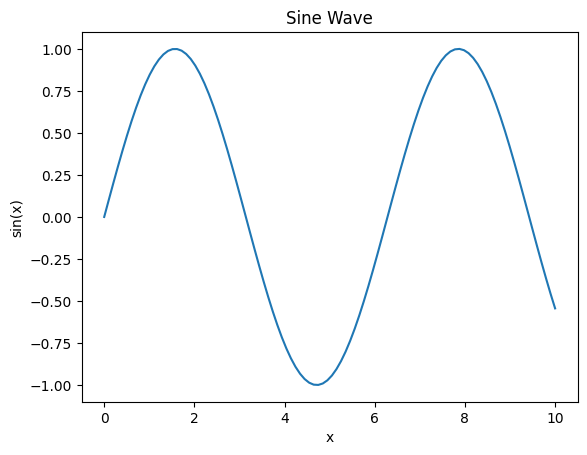

In [ ]:
x = np.linspace(0, 10, 100)
plt.plot(x, np.sin(x))
plt.title('Sine Wave')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 3-1 iris로 여러 그래프 그리기</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 아래 셀들을 차례로 실행하며 <b>히스토그램·산점도·박스플롯·막대그래프</b>로 iris 의 특성을 살펴보세요.<br><b>힌트</b> &nbsp; <code>plt.hist</code> · <code>plt.scatter</code> · <code>sns.boxplot</code> · <code>plt.bar</code> · 여러 그림은 <code>plt.subplot</code><br><b>예상</b> &nbsp; 종(species)별로 분포가 또렷이 갈리는 그림들
</div>
</div>

In [ ]:
# 1. 히스토그램 - 각 특성의 분포 확인
plt.figure(figsize=(12, 8))

# 2x2 서브플롯 생성
plt.subplot(2, 2, 1)
plt.hist(iris['sepal_length'], bins=20, alpha=0.7, color='skyblue')
plt.title('꽃받침 길이 분포')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('빈도')

plt.subplot(2, 2, 2)
plt.hist(iris['sepal_width'], bins=20, alpha=0.7, color='lightcoral')
plt.title('꽃받침 너비 분포')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('빈도')

plt.subplot(2, 2, 3)
plt.hist(iris['petal_length'], bins=20, alpha=0.7, color='lightgreen')
plt.title('꽃잎 길이 분포')
plt.xlabel('Petal Length (cm)')
plt.ylabel('빈도')

plt.subplot(2, 2, 4)
plt.hist(iris['petal_width'], bins=20, alpha=0.7, color='gold')
plt.title('꽃잎 너비 분포')
plt.xlabel('Petal Width (cm)')
plt.ylabel('빈도')

plt.tight_layout()
plt.show()


In [ ]:
# 2. 산점도 - 두 변수 간의 관계
plt.figure(figsize=(10, 6))

# 종별로 다른 색상 지정
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

for species in iris['species'].unique():
    species_data = iris[iris['species'] == species]
    plt.scatter(species_data['sepal_length'], species_data['petal_length'],
                c=colors[species], label=species, alpha=0.7, s=50)

plt.xlabel('꽃받침 길이 (Sepal Length)')
plt.ylabel('꽃잎 길이 (Petal Length)')
plt.title('꽃받침 길이 vs 꽃잎 길이 (종별 구분)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# 3. 박스플롯 - 종별 특성 비교
plt.figure(figsize=(12, 8))

# 각 특성별로 종별 박스플롯
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feature_names = ['꽃받침 길이', '꽃받침 너비', '꽃잎 길이', '꽃잎 너비']

for i, (feature, name) in enumerate(zip(features, feature_names)):
    plt.subplot(2, 2, i+1)

    # 종별 데이터 준비
    setosa_data = iris[iris['species'] == 'setosa'][feature]
    versicolor_data = iris[iris['species'] == 'versicolor'][feature]
    virginica_data = iris[iris['species'] == 'virginica'][feature]

    # 박스플롯 그리기
    plt.boxplot([setosa_data, versicolor_data, virginica_data],
                tick_labels=['setosa', 'versicolor', 'virginica'])
    plt.title(f'{name} 종별 비교')
    plt.ylabel('값 (cm)')

plt.tight_layout()
plt.show()


In [ ]:
# 4. 막대그래프 - 종별 평균값 비교
plt.figure(figsize=(12, 5))

# 종별 평균 계산
species_mean = iris.groupby('species')[['sepal_length', 'petal_length']].mean()

plt.subplot(1, 2, 1)
species_mean['sepal_length'].plot(kind='bar', color=['coral', 'lightblue', 'lightgreen'])
plt.title('종별 꽃받침 길이 평균')
plt.ylabel('평균 길이 (cm)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
species_mean['petal_length'].plot(kind='bar', color=['coral', 'lightblue', 'lightgreen'])
plt.title('종별 꽃잎 길이 평균')
plt.ylabel('평균 길이 (cm)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# 6. 종합 대시보드 - 한 화면에 여러 그래프
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Iris 데이터셋 종합 분석', fontsize=16)

# 1. 종별 개수 파이차트
species_counts = iris['species'].value_counts()
axes[0, 0].pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%',
               colors=['lightcoral', 'lightblue', 'lightgreen'])
axes[0, 0].set_title('종별 비율')

# 2. 꽃받침 길이 vs 너비 산점도
for species, color in zip(iris['species'].unique(), ['red', 'blue', 'green']):
    species_data = iris[iris['species'] == species]
    axes[0, 1].scatter(species_data['sepal_length'], species_data['sepal_width'],
                      c=color, label=species, alpha=0.6)
axes[0, 1].set_xlabel('꽃받침 길이')
axes[0, 1].set_ylabel('꽃받침 너비')
axes[0, 1].set_title('꽃받침 길이 vs 너비')
axes[0, 1].legend()

# 3. 꽃잎 길이 히스토그램
axes[0, 2].hist(iris['petal_length'], bins=20, alpha=0.7, color='purple')
axes[0, 2].set_xlabel('꽃잎 길이')
axes[0, 2].set_ylabel('빈도')
axes[0, 2].set_title('꽃잎 길이 분포')

# 4. 종별 꽃받침 길이 박스플롯
setosa = iris[iris['species'] == 'setosa']['sepal_length']
versicolor = iris[iris['species'] == 'versicolor']['sepal_length']
virginica = iris[iris['species'] == 'virginica']['sepal_length']
axes[1, 0].boxplot([setosa, versicolor, virginica],
                   tick_labels=['setosa', 'versicolor', 'virginica'])
axes[1, 0].set_ylabel('꽃받침 길이')
axes[1, 0].set_title('종별 꽃받침 길이')

# 5. 종별 평균값 막대그래프
species_avg = iris.groupby('species')['petal_length'].mean()
axes[1, 1].bar(species_avg.index, species_avg.values,
               color=['lightcoral', 'lightblue', 'lightgreen'])
axes[1, 1].set_ylabel('평균 꽃잎 길이')
axes[1, 1].set_title('종별 평균 꽃잎 길이')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. 꽃잎 길이 vs 너비 산점도
for species, color in zip(iris['species'].unique(), ['red', 'blue', 'green']):
    species_data = iris[iris['species'] == species]
    axes[1, 2].scatter(species_data['petal_length'], species_data['petal_width'],
                      c=color, label=species, alpha=0.6)
axes[1, 2].set_xlabel('꽃잎 길이')
axes[1, 2].set_ylabel('꽃잎 너비')
axes[1, 2].set_title('꽃잎 길이 vs 너비')
axes[1, 2].legend()

plt.tight_layout()
plt.show()


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 3-2 선 그래프 직접 그리기</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 월별 판매량 <code>sales = [3, 7, 2, 8, 5]</code> 를 <b>선 그래프</b>로 그리세요. 마커를 표시하고 <b>제목·x·y축 라벨</b>을 붙입니다.<br><b>힌트</b> &nbsp; <code>plt.plot(sales, marker=..)</code> · <code>plt.title / plt.xlabel / plt.ylabel</code> · <code>plt.show()</code><br><b>예상</b> &nbsp; 5개 점을 잇는 꺾은선 그래프
</div>
</div>

In [ ]:
# ✏️ 연습 3-2 — 직접 작성 (월별 판매량 꺾은선 그래프)
sales = [3, 7, 2, 8, 5]
# 여기에 코드를 작성하세요 (plt.plot 에 marker 지정, 제목·축라벨 추가 후 plt.show())

## 4. Seaborn 기초

Seaborn은 matplotlib을 기반으로 한 통계 시각화 라이브러리입니다. 더 아름답고 통계적으로 유용한 그래프를 쉽게 만들 수 있습니다.


In [ ]:
# 1. Pairplot - 모든 변수 간의 관계를 한 번에 보기
print("모든 특성 간의 관계를 한 번에 시각화:")
plt.figure(figsize=(12, 10))

# 종별로 다른 색상으로 pairplot 생성
g = sns.pairplot(iris, hue='species', diag_kind='hist',
                 palette=['red', 'blue', 'green'])
g.fig.suptitle('Iris Dataset - 모든 특성 간의 관계', y=1.02, fontsize=16)
plt.show()


In [ ]:
# 2. Heatmap - 상관관계를 더 예쁘게 시각화
plt.figure(figsize=(8, 6))

# 수치형 데이터만 선택하여 상관계수 계산
numeric_data = iris.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()

# seaborn으로 더 예쁜 히트맵 생성
sns.heatmap(correlation_matrix,
            annot=True,          # 셀에 상관계수 값 표시
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            fmt='.2f')

plt.title('Iris Dataset 특성 간 상관관계 (Seaborn)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


In [ ]:
# 4. 간단한 Seaborn 그래프들 - 한 줄로 예쁜 그래프 그리기!

# countplot - 카테고리별 개수 세기 (막대그래프)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.countplot(data=iris, x='species', palette='Set2')
plt.title('종별 개수')

# boxplot - 상자 그림
plt.subplot(1, 3, 2)
sns.boxplot(data=iris, x='species', y='sepal_length', palette='Set3')
plt.title('종별 꽃받침 길이')

# scatterplot - 산점도 (자동으로 예쁘게!)
plt.subplot(1, 3, 3)
sns.scatterplot(data=iris, x='sepal_length', y='petal_length', hue='species')
plt.title('꽃받침 vs 꽃잎 길이')

plt.tight_layout()
plt.show()

print("💡 Seaborn은 data=DataFrame만 넣으면 알아서 예쁘게 그려줍니다!")

In [ ]:
# 3. Violin Plot - 분포 형태와 밀도를 함께 보기
plt.figure(figsize=(14, 8))

# 각 특성별로 종별 violin plot
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feature_names = ['꽃받침 길이', '꽃받침 너비', '꽃잎 길이', '꽃잎 너비']

for i, (feature, name) in enumerate(zip(features, feature_names)):
    plt.subplot(2, 2, i+1)

    # violin plot 생성
    sns.violinplot(data=iris, x='species', y=feature,
                   palette=['lightcoral', 'lightblue', 'lightgreen'])

    plt.title(f'{name} 분포 (종별)', fontsize=12)
    plt.xlabel('종')
    plt.ylabel(f'{name} (cm)')

plt.suptitle('Iris Dataset - Violin Plot으로 보는 종별 분포', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습 4-1 Seaborn 산점도 직접 그리기</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>iris</code> 의 <code>sepal_length</code>(x)와 <code>petal_length</code>(y) 산점도를 <b>종(species)별 색</b>으로 Seaborn으로 그리세요.<br><b>힌트</b> &nbsp; <code>sns.scatterplot(x=.., y=.., hue='species', data=iris)</code> · <code>plt.show()</code><br><b>예상</b> &nbsp; 세 종이 색으로 구분된 산점도
</div>
</div>

In [ ]:
# ✏️ 연습 4-1 — 직접 작성 (종별 색 산점도)
# 여기에 코드를 작성하세요 (sns.scatterplot 사용, hue='species', 이후 plt.show())

<div style="margin:20px 0 4px;padding:14px 20px;border-radius:10px;background:#F4E7DF;border:1px solid #E7DCC6;">
<span style="font-size:19px;font-weight:800;color:#23211C;">✏️ 종합 연습문제 — 직접 풀어 보세요</span><br>
<span style="color:#5A5448;font-size:14px;line-height:1.7;">지금까지 배운 NumPy·pandas·Matplotlib·Seaborn 을 한데 써 봅니다. 모든 문제는 위에서 만든 <code>iris</code> 데이터와 <code>np</code>·<code>plt</code>·<code>sns</code> 를 그대로 씁니다. 앞쪽은 <b>빈칸(____) 채우기</b>, 뒤로 갈수록 <b>직접 작성</b>입니다. 막히면 위쪽 해당 셀을 참고하세요.</span>
</div>

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 종합 1 NumPy 5의 배수 통계</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 1~50 중 <b>5의 배수만</b> 담은 배열을 만들고 <b>평균·합계·최댓값</b>을 출력하세요.<br><b>힌트</b> &nbsp; <code>np.arange(시작, 끝, 간격)</code> 로 배열 · 평균·합계·최댓값은 각각의 통계 메서드<br><b>예상</b> &nbsp; 평균 27.5 · 합계 275 · 최댓값 50
</div>
</div>

In [ ]:
# ✏️ 종합 1 — 직접 작성 (1~50 중 5의 배수 배열을 만들고 평균·합계·최댓값 출력)
multiples_of_5 = ____   # ← 1~50 사이 5의 배수만 담은 배열
print('평균:', ____)     # ← 평균
print('합계:', ____)     # ← 합계
print('최댓값:', ____)   # ← 최댓값

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 종합 2 pandas 복합 조건 필터</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; iris 에서 <b>versicolor 종</b>이면서 <code>petal_length ≥ 4.0</code> 인 행만 골라 <b>몇 개</b>인지 출력하세요.<br><b>힌트</b> &nbsp; 두 조건을 <code>&</code> 로 결합(각 조건은 괄호) · 개수는 <code>len(...)</code><br><b>예상</b> &nbsp; 수십 개 규모의 정수 하나
</div>
</div>

In [ ]:
# ✏️ 종합 2 — 직접 작성 (versicolor 이면서 petal_length 가 4.0 이상인 행의 개수 출력)
result = ____   # ← versicolor 종이면서 petal_length 가 4.0 이상인 행만 거르기
print(f"조건을 만족하는 행 수: {____}개")   # ← 그 행이 몇 개인지

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 종합 3 Matplotlib 막대그래프 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 학생 5명의 점수 <code>[78, 85, 92, 67, 89]</code> 를 <b>막대그래프</b>로 그리세요. (x축 학생1~5, y축 점수)<br><b>힌트</b> &nbsp; <code>plt.bar(이름목록, 점수목록)</code> · 제목·축 라벨은 <code>plt.title</code>·<code>plt.xlabel</code>·<code>plt.ylabel</code><br><b>예상</b> &nbsp; 학생별 점수 높이가 다른 막대 5개
</div>
</div>

In [ ]:
# ✏️ 직접 작성 — 점수 [78,85,92,67,89] 를 학생1~5 막대그래프로
names = ['학생1', '학생2', '학생3', '학생4', '학생5']
scores = [78, 85, 92, 67, 89]
____              # ← names(x축), scores(y축) 로 막대그래프 그리기
____              # ← 그래프 제목 달기
plt.show()

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 종합 4 Seaborn 박스플롯 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; iris 의 <code>petal_width</code> 에 대해 <b>종별 박스플롯</b>을 Seaborn 으로 그리세요.<br><b>힌트</b> &nbsp; Seaborn 의 <code>sns.boxplot</code> 에 <code>data</code> · <code>x</code>(종) · <code>y</code>(값 열) 를 지정<br><b>예상</b> &nbsp; 종마다 상자 높이·위치가 다른 세 개의 박스
</div>
</div>

In [ ]:
# ✏️ 직접 작성 — petal_width 의 종별 박스플롯을 seaborn 으로
____   # ← seaborn 박스플롯: x=종(species), y=petal_width
plt.show()

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">🎯 종합문제 종별 평균 + 차이 분석 <span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">종합</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; iris 를 <b>종별로 그룹</b>지어 <code>petal_width</code> <b>평균</b>을 구하고, <b>막대그래프</b>로 그린 뒤 <b>평균이 가장 큰 종의 이름</b>과 <b>(최대−최소) 평균 차이</b>를 출력하세요.<br><b>힌트</b> &nbsp; 종별 평균은 <code>groupby('species')</code> · 막대는 <code>.plot(kind='bar')</code> · 가장 큰 종 이름은 <code>idxmax</code>, 차이는 최댓값−최솟값<br><b>예상</b> &nbsp; setosa 가 가장 작고 virginica 가 가장 큰 계단형 막대 · 가장 큰 종 virginica · 차이 약 1.78
</div>
</div>

In [ ]:
# ✏️ 종합문제 — 처음부터 직접 작성해 보세요
# 목표: iris 를 종별로 그룹지어 petal_width 평균 -> 막대그래프 -> 평균이 가장 큰 종 이름과 (최대-최소) 차이 출력
petal_mean = ____   # ← 종별 petal_width 평균 (species 로 그룹지어 평균)
____                # ← petal_mean 을 막대그래프로 그리기
plt.show()
print("평균이 가장 큰 종:", ____)      # ← 평균이 가장 큰 종의 이름
print("최대-최소 평균 차이:", ____)    # ← 평균의 (최댓값 - 최솟값)

## 🔑 막히면 펼쳐보기 (힌트)

아래 힌트는 **쓸 함수·메서드 이름과 접근 방법**만 알려줍니다. 완성 코드가 아니니, 먼저 스스로 작성해 본 뒤 정말 막힐 때만 펼쳐 보세요.

<details><summary>연습 1-3 · 무작위 생성과 정렬</summary>

- 0~1 균등분포 난수 10개: <code>np.random.rand(개수)</code>
- 오름차순 정렬: <code>np.sort(배열)</code> — 원본을 정렬한 새 배열을 돌려줍니다.

</details>

<details><summary>연습 2-3 · 필터 + 열 선택 + 정렬</summary>

- 조건으로 행 거르기: <code>df[df['petal_length'] >= 4.0]</code>
- 원하는 열만 남기기: <code>[['열1', '열2']]</code> (대괄호 두 겹)
- 정렬: <code>.sort_values('열', ascending=False)</code>
- 세 단계를 <code>subset</code> 에 순서대로 이어서 적용합니다.

</details>

<details><summary>종합 1 · 5의 배수 통계</summary>

- 등차 배열: <code>np.arange(시작, 끝, 간격)</code> — 끝 값은 포함되지 않으니 51 까지 잡습니다.
- 평균·합계·최댓값: 배열의 <code>.mean()</code> · <code>.sum()</code> · <code>.max()</code>

</details>

<details><summary>종합 2 · 복합 조건 필터</summary>

- 두 조건을 <code>&</code> 로 결합하고, 각 조건은 괄호로 감쌉니다: <code>(조건1) & (조건2)</code>
- 종 비교는 <code>iris['species'] == 'versicolor'</code>, 개수는 <code>len(...)</code>

</details>

<details><summary>종합 3 · 막대그래프</summary>

- 막대: <code>plt.bar(x목록, y목록)</code> (여기선 x=names, y=scores)
- 제목: <code>plt.title('...')</code> · 축 라벨은 <code>plt.xlabel</code> · <code>plt.ylabel</code>

</details>

<details><summary>종합 4 · Seaborn 박스플롯</summary>

- <code>sns.boxplot(data=iris, x='species', y='petal_width')</code> 형태로 data · x · y 를 지정합니다.

</details>

<details><summary>종합문제 · 종별 평균 + 차이 분석</summary>

- 종별 평균: <code>iris.groupby('species')['petal_width'].mean()</code>
- 막대그래프: 위 결과에 <code>.plot(kind='bar')</code>
- 가장 큰 종 이름: <code>.idxmax()</code>
- 차이: 평균의 <code>.max() - .min()</code>

</details>

<details><summary>연습 2-1 · Series 통계</summary>

- Series도 배열처럼 <code>.mean()</code> · <code>.max()</code> 메서드를 그대로 씁니다.

</details>

<details><summary>연습 2-2 · 필터 + 열 선택 + 정렬(students)</summary>

- 조건 필터: <code>students[students['수학'] >= 88]</code>
- 두 열만: 뒤에 <code>[['이름', '수학']]</code> (대괄호 두 겹)
- 내림차순: <code>.sort_values('수학', ascending=False)</code>

</details>

<details><summary>연습 3-2 · 선 그래프 직접 그리기</summary>

- 꺾은선+마커: <code>plt.plot(sales, marker='o')</code>
- 꾸미기: <code>plt.title(...)</code> · <code>plt.xlabel(...)</code> · <code>plt.ylabel(...)</code>
- 마지막에 <code>plt.show()</code>

</details>

<details><summary>연습 4-1 · Seaborn 산점도</summary>

- <code>sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=iris)</code>
- <code>hue='species'</code> 를 주면 종별로 색이 달라집니다. 그린 뒤 <code>plt.show()</code>.

</details>


## 요약

이번 실습에서 배운 내용:

### NumPy
- 다차원 배열 생성 및 조작
- 브로드캐스팅을 통한 벡터화 연산

### pandas
- DataFrame과 Series 생성 및 조작
- 데이터 선택, 필터링, 정렬, 집계
- CSV 파일 읽기 및 기본 통계 분석

### Matplotlib
- 히스토그램, 산점도, 박스플롯, 막대그래프
- 서브플롯을 활용한 다중 그래프
- 상관관계 히트맵
- 종합 대시보드 구성

### Seaborn
- Pairplot을 통한 모든 변수 관계 시각화
- Violin plot으로 분포 형태와 밀도 표현

